# Knock Airport Weather Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [2]:
# Loading data from a URL resulted in error due to header rows
# Skipping the first 23 rows to get to the actual data
# Using low_memory=False to avoid dtype warning
df = pd.read_csv("https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv", skiprows=23, low_memory=False)


df.head(3)

,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
0,10-apr-1996 14:00,0,0.0,0,11.5,0,8.1,3.9,0.0,0,...,0,0,0,0,25,81,0.0,35000,32,5
1,31-jul-1996 08:00,0,0.0,0,11.5,0,11.1,10.7,0.0,0,...,0,0,0,0,25,82,0.0,40000,45,5
2,31-jul-1996 09:00,0,0.0,0,11.6,0,10.7,9.8,0.0,0,...,0,0,0,0,80,81,0.0,8000,32,7


## Convert date column

In [ ]:
# Convert 'date' column to datetime format
# Pass 'mixed' to handle different date formats in the column (without format argument pandas shows warning)
df['date']= pd.to_datetime(df['date'], format='mixed')

# Check the date column format changed to datetime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256434 entries, 0 to 256433
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    256434 non-null  datetime64[ns]
 1   ind     256434 non-null  int64         
 2   rain    256434 non-null  object        
 3   ind.1   256434 non-null  int64         
 4   temp    256434 non-null  float64       
 5   ind.2   256434 non-null  int64         
 6   wetb    256434 non-null  float64       
 7   dewpt   256434 non-null  float64       
 8   vappr   256434 non-null  float64       
 9   rhum    256434 non-null  int64         
 10  msl     256434 non-null  object        
 11  ind.3   256434 non-null  int64         
 12  wdsp    256434 non-null  object        
 13  ind.4   256434 non-null  int64         
 14  wddir   256434 non-null  object        
 15  ww      256434 non-null  object        
 16  w       256434 non-null  object        
 17  sun     256434 non-null  floa

In [4]:
# Set 'date' column as index for resampling
df = df.set_index('date') 

df.tail(3)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
date,,,,,,,,,,,,,,,,,,,,
2025-10-31 22:00:00,0,0.5,0,7.8,0,7.6,7.3,10.3,97,983.1,2,10,2,160,,,0.0,6000,43,8
2025-10-31 23:00:00,0,0.8,0,7.4,0,7.3,7.2,10.1,99,982.9,2,8,2,160,,,0.0,9000,46,8
2025-11-01 00:00:00,0,0.2,0,7.4,0,7.4,7.3,10.3,100,982.9,2,7,2,190,,,0.0,25000,1,8


## Visualize data

Use [matplotlib.pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) capabilities to visualize data.

# Tempreture

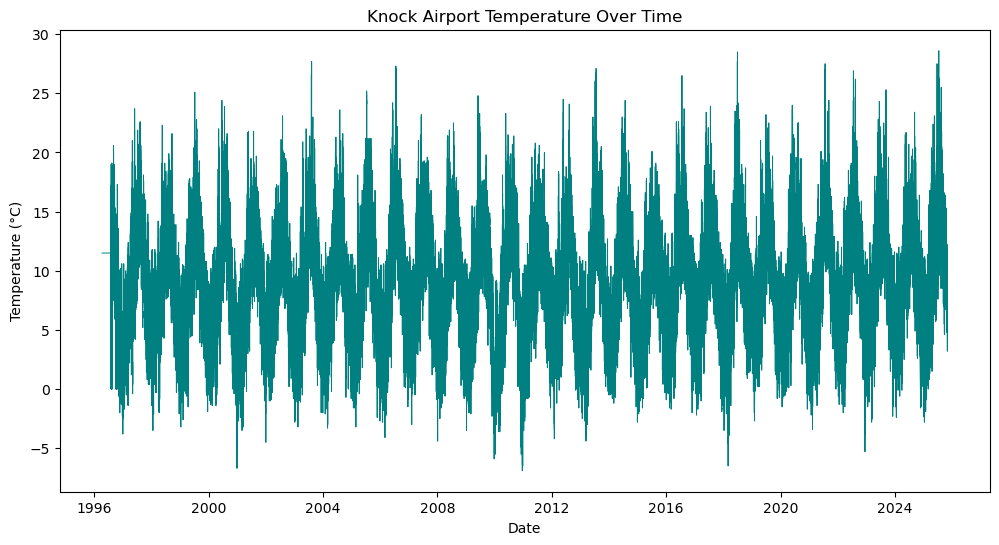

In [ ]:
# Plot temperature data
fix, ax = plt.subplots(figsize=(12, 6))

# Create a plot to visualize temperature over time
ax.plot(df["temp"], linewidth=0.7, color='teal')

# Set plot title and labels
ax.set_title("Knock Airport Temperature Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")

plt.show()

This graph shows hourly temperatures from July 31, 1996 (including a single temperature measurement on April 10, 1996, which might be a test sample), up to the end of November 2025. Overall, the plot displays a dense line that reflects both daily and annual temperature patterns. The daily fluctuations represent typical daytime highs and nighttime lows, while the annual cycle highlights higher temperatures in summer and lower temperatures in winter.

## Closer look at tempreture

To confirm the observations above, we can take a more detailed look at the data—specifically by examining the two-year seasonal trend and the daily temperature pattern.

## Two-year tempreture trend

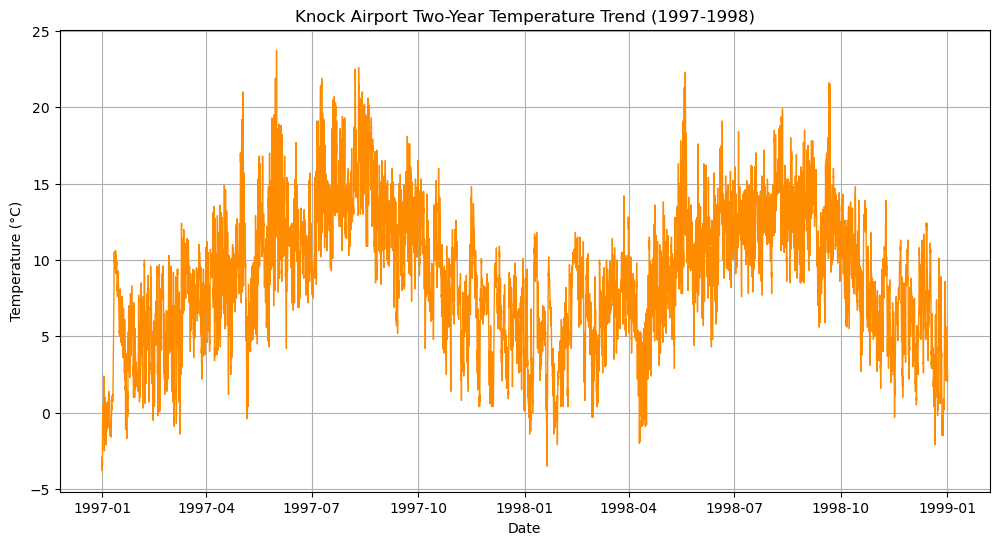

In [ ]:
# Set Start and End date for the period we want to analyse
dateFrom = "1997-01-01 01:00:00"
dateTo = "1999-01-01 01:00:00"

# Plot temperature data for the selected period
fix, ax = plt.subplots(figsize=(12, 6))

# Use df.loc to filter data within the specified date range
ax.plot(df.loc[dateFrom:dateTo]["temp"], linewidth=1, color='darkorange')
ax.set_title("Knock Airport Two-Year Temperature Trend (1997-1998)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
# Add grid for better readability
ax.grid()

plt.show()

This plot demonstrates seasonality and its impact on temperatures in a more apparent way. For example, temperatures typically drop below 5°C from around October until May, with some exceptions. Likewise, temperatures generally rise above 15°C from May through October.

## Daily tempreture trend

Let's look at seven-day tempreture trend in March 1996.

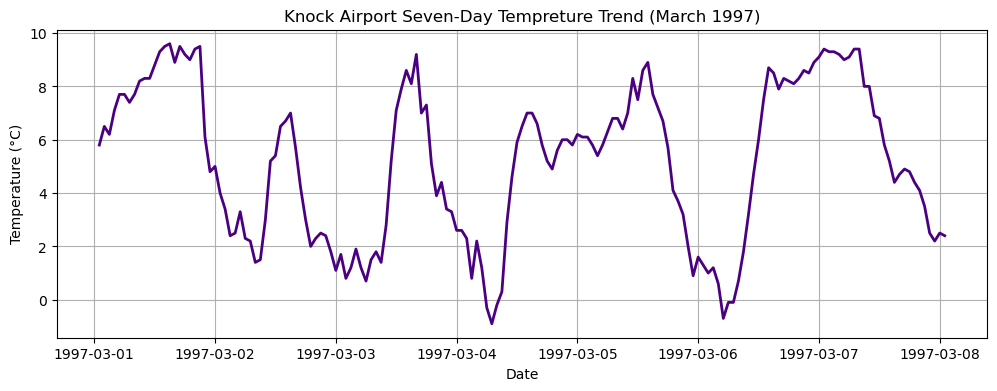

In [ ]:
# Set Start and End date for daily plot
dateFrom = "1997-03-01 01:00:00"
dateTo = "1997-03-08 01:00:00"

# Plot data
fix, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.loc[dateFrom:dateTo]["temp"], linewidth=2, color='indigo')
ax.set_title("Knock Airport Seven-Day Tempreture Trend (March 1997)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid()

plt.show()

Similarly, this 7-day weather plot from March 1997 releals a clear pattern of daily temperature fluctuations.

# Daily Mean Tempreture

Compute the daily and monthly **mean** tempretures using the `pandas` [resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) method. This method allows to group the data by a specified time period and apply aggregation functions, such as calculating the average temperature for each day or month. For period aliases I referred to the [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#period-aliases).

In [8]:
# Daily mean temperature
# Pass 'D' alias to resample method for daily frequency
df_daily = df["temp"].resample("D").mean()

df_daily.tail(3)

date
2025-10-30    7.887500
2025-10-31    9.670833
2025-11-01    7.400000
Freq: D, Name: temp, dtype: float64

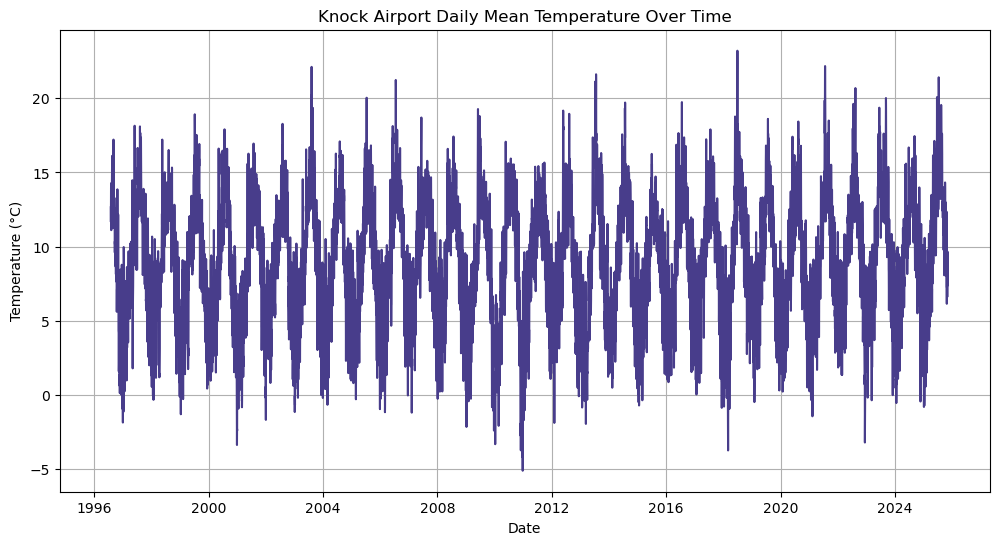

In [25]:
# Plot daily mean temperature data
fix, ax = plt.subplots(figsize=(12, 6))

# Create a plot to visualize daily mean temperature
ax.plot(df_daily, color='darkslateblue')
ax.set_title("Knock Airport Daily Mean Temperature Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid()

plt.show()

# Monthly Mean Tempreture

In [ ]:
# Pass 'M' alias to resample method for monthly frequency
df_monthly = df["temp"].resample("M").mean()

df_monthly.tail(3)

date
2025-09-30    11.368056
2025-10-31     9.900134
2025-11-30     7.400000
Freq: M, Name: temp, dtype: float64

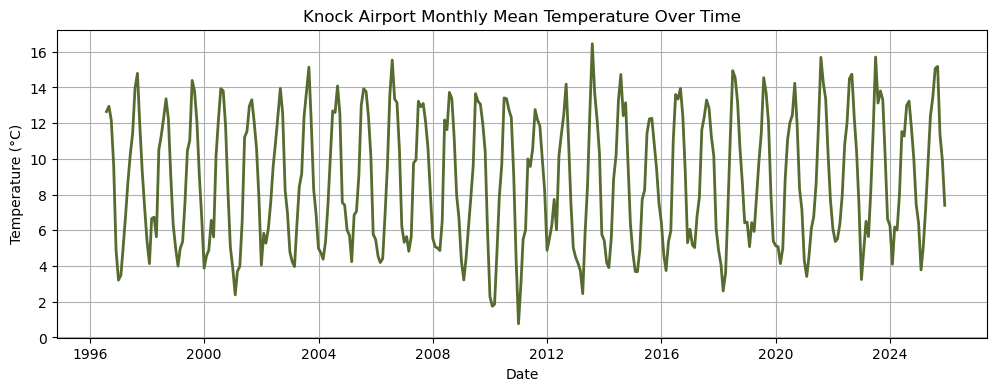

In [ ]:
# Plot monthly mean temperature data
fix, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_monthly, linewidth=2, color='darkolivegreen')
ax.set_title("Knock Airport Monthly Mean Temperature Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid()

plt.show()

# Windspeed

Per the dataset documentation, the `wdsp` column represents *Mean Hourly Wind Speed (kt)*. The column contains some missing values (blank entries), which we can handle using `pandas.to_numeric` method (see [documentation](https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html)) to convert them to `NaN` for further calculations and analysis. 

This column also contains zero values, which we keep as valid observations, assuming they represent calm wind conditions.

In [12]:
# Convert 'wdsp' column to numeric, forcing errors to NaN
df['wdsp'] = pd.to_numeric(df['wdsp'], errors='coerce')

# Check the column type to confirm it was converted to numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 256434 entries, 1996-04-10 14:00:00 to 2025-11-01 00:00:00
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ind     256434 non-null  int64  
 1   rain    256434 non-null  object 
 2   ind.1   256434 non-null  int64  
 3   temp    256434 non-null  float64
 4   ind.2   256434 non-null  int64  
 5   wetb    256434 non-null  float64
 6   dewpt   256434 non-null  float64
 7   vappr   256434 non-null  float64
 8   rhum    256434 non-null  int64  
 9   msl     256434 non-null  object 
 10  ind.3   256434 non-null  int64  
 11  wdsp    256384 non-null  float64
 12  ind.4   256434 non-null  int64  
 13  wddir   256434 non-null  object 
 14  ww      256434 non-null  object 
 15  w       256434 non-null  object 
 16  sun     256434 non-null  float64
 17  vis     256434 non-null  object 
 18  clht    256434 non-null  object 
 19  clamt   256434 non-null  object 
dtypes: float64(6),

## Visualize wind speed data

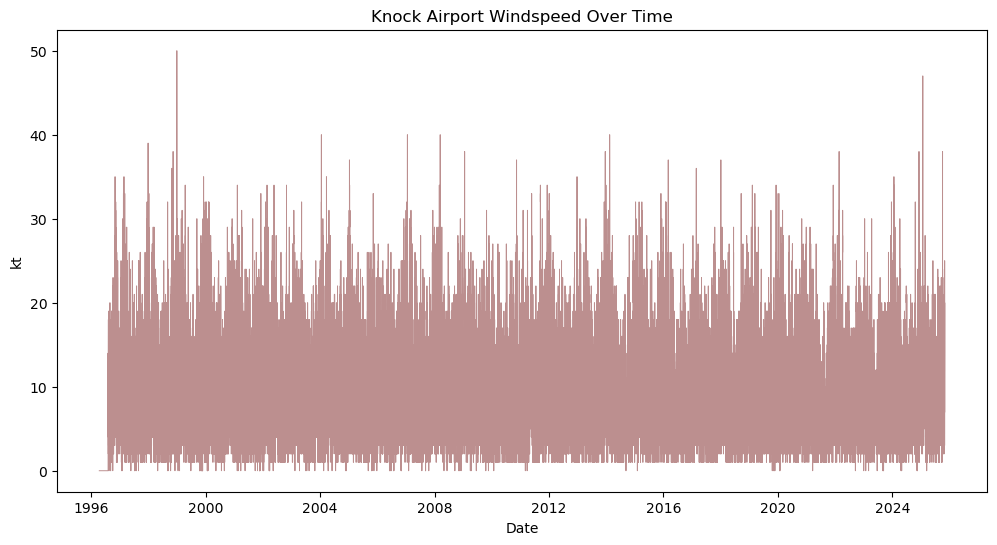

In [28]:
# Plot wind spead data
fix, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['wdsp'], linewidth=0.7, color='rosybrown')
ax.set_title("Knock Airport Windspeed Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("kt")

plt.show()

This graph is difficult to read due to the large volume of hourly data in the dataset. To draw meaningful insights, it makes sense to isolate a smaller time period for analysis. For example, we can examine a single month of data—such as March 2025.

## Wind spead daily trend

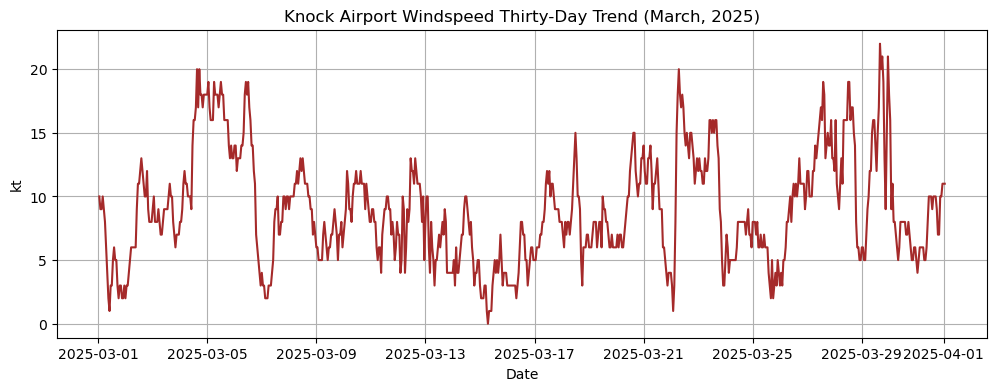

In [30]:
# Set Start and End date for daily plot
dateFrom = "2025-03-01 01:00:00"
dateTo = "2025-04-01 01:00:00"

# Plot wind spead data for March 2025
fix, ax = plt.subplots(figsize=(12, 4))


ax.plot(df.loc[dateFrom:dateTo]['wdsp'], color='brown')
ax.set_title("Knock Airport Windspeed Thirty-Day Trend (March, 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("kt")
ax.grid()

plt.show()

# The rolling windspeed

Explanation on rolling window calculation was explored through [Scaler Topics](https://www.scaler.com/topics/pandas/resampling-in-pandas/), [Geekforgeeks](https://www.geeksforgeeks.org/python/python-pandas-dataframe-rolling/) as well as pandas [official documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html).

In [15]:
# Rolling windspeed calculation with a 24-hour window
# If we have not enough data points to fill the window, the result will be NaN
df_rolling = df['wdsp'].rolling(window=24).mean()

df_rolling

date
1996-04-10 14:00:00          NaN
1996-07-31 08:00:00          NaN
1996-07-31 09:00:00          NaN
1996-07-31 10:00:00          NaN
1996-07-31 11:00:00          NaN
                         ...    
2025-10-31 20:00:00    17.166667
2025-10-31 21:00:00    16.958333
2025-10-31 22:00:00    16.625000
2025-10-31 23:00:00    16.166667
2025-11-01 00:00:00    15.625000
Name: wdsp, Length: 256434, dtype: float64

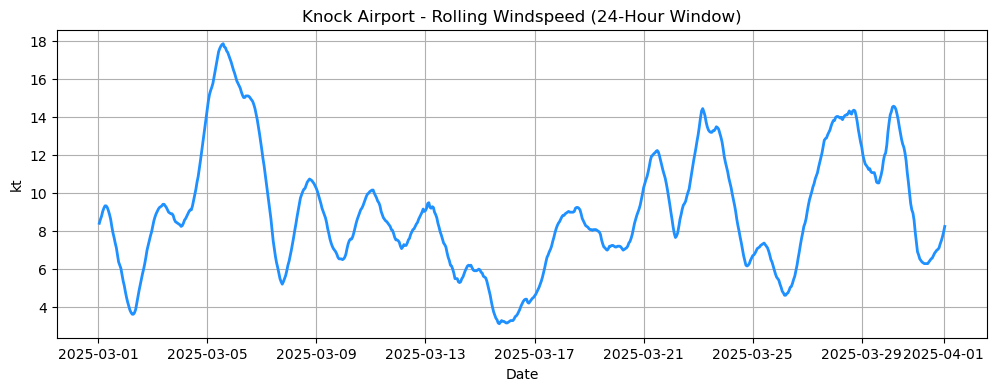

In [16]:
# Plot rolling windspeed data
fix, ax = plt.subplots(figsize=(12, 4))

# Pass previously calculated rolling data to the plot function
# Pass the date range to focus on March 2025 (for reasonable visualization)
ax.plot(df_rolling.loc[dateFrom:dateTo], linewidth=2, color='dodgerblue')
ax.set_title("Knock Airport - Rolling Windspeed (24-Hour Window)")
ax.set_xlabel("Date")
ax.set_ylabel("kt")
ax.grid()

plt.show()

A rolling mean smooths out the hourly wind speed fluctuations, creating a clearer and more easily interpretable visualization that highlights the underlying trend over a given time period.

# The daily max windspeed

To calculate the maximum windspeed for each day, we can use the `resample()` method with a daily frequency, followed by the `.max()` aggregation (see [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.max.html)). This groups the data by day and returns the highest windspeed observed within specified frequency.

In [31]:
# Resample windspeed data to daily maximum values
# Pass 'D' alias to resample method for daily frequency
df_daily_max = df['wdsp'].resample("D").max()

df_daily_max .tail(3)

date
2025-10-30    25.0
2025-10-31    20.0
2025-11-01     7.0
Freq: D, Name: wdsp, dtype: float64

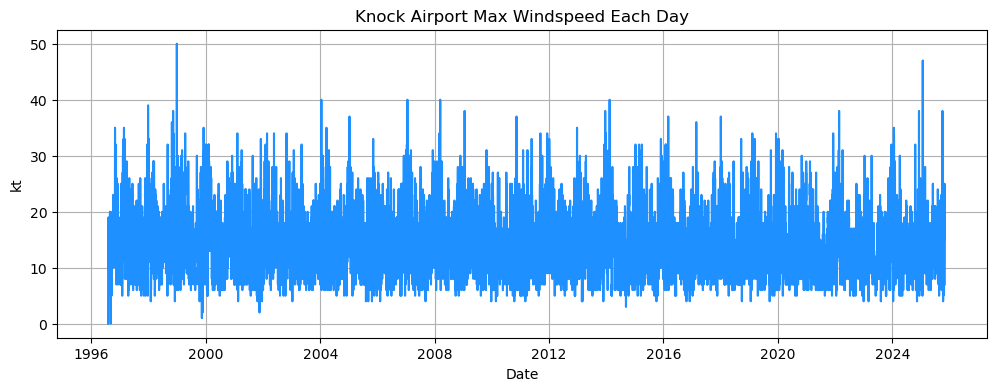

In [32]:
# Plot daily max windspeed data
fix, ax = plt.subplots(figsize=(12, 4))

# Pass previously calculated daily max speed data to the plot function
ax.plot(df_daily_max, color='dodgerblue')
ax.set_title("Knock Airport Max Windspeed Each Day")
ax.set_xlabel("Date")
ax.set_ylabel("kt")
ax.grid()

plt.show()

## Closer look at max windspeed

We can look at 2025 max windspeed for each day. Note that, at the time of preparing this notebook, data is available for only 11 months.

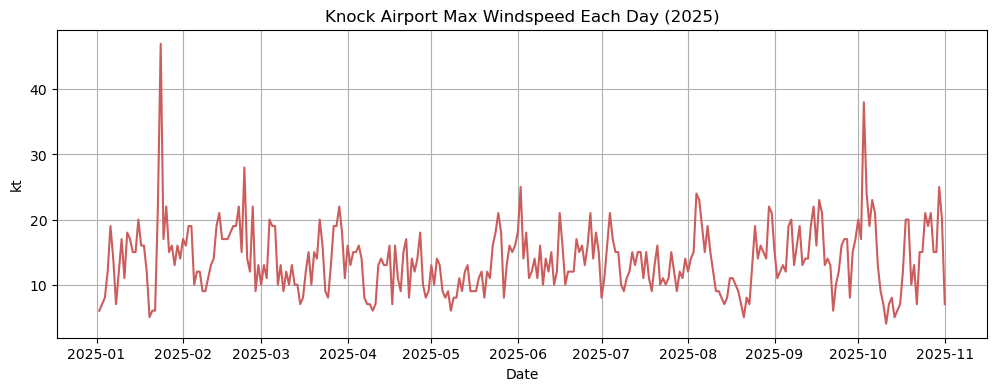

In [33]:
# Set Start and End date
dateFrom = "2025-01-01 01:00:00"
dateTo = "2025-12-01 01:00:00"

fix, ax = plt.subplots(figsize=(12, 4))

# Pass previously calculated daily max speed data 
# Pass the date range to focus on 2025
ax.plot(df_daily_max.loc[dateFrom:dateTo], color='indianred')
ax.set_title("Knock Airport Max Windspeed Each Day (2025)")
ax.set_xlabel("Date")
ax.set_ylabel("kt")
ax.grid()

plt.show()

The plot demonstrates max windspeed trend in 2025, revealing 2 stormy days in late January and early October.

# The monthly mean of the daily max windspeeds

We can either take the previously calculated `df_daily_max` and resample it at a monthly frequency to compute the monthly `mean` of that, or we can chain the operations into a single expression so the full transformation is visible in one place. 

The code below first resamples the hourly wind speeds to daily frequency and calculates the daily maximum, and then resamples those daily values to monthly frequency and computes the monthly mean.

In [20]:
# The monthly mean of the daily max windspeeds
df_monthly_mean_of_daily_max = df['wdsp'].resample("D").max().resample("M").mean()

df_monthly_mean_of_daily_max.tail(3)

date
2025-09-30    15.000000
2025-10-31    15.354839
2025-11-30     7.000000
Freq: M, Name: wdsp, dtype: float64

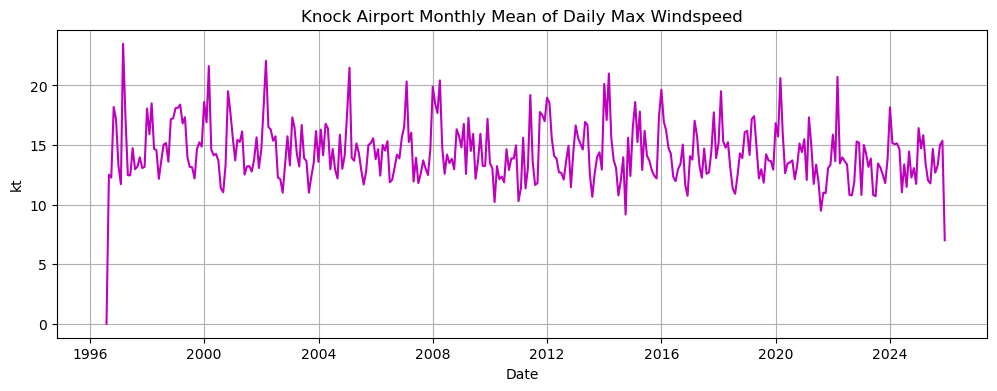

In [34]:
# Plot monthly mean of daily max windspeed data
fix, ax = plt.subplots(figsize=(12, 4))

# Pass previously calculated monthly mean of daily max windspeed data 
ax.plot(df_monthly_mean_of_daily_max, color='m')
ax.set_title("Knock Airport Monthly Mean of Daily Max Windspeed")
ax.set_xlabel("Date")
ax.set_ylabel("kt")
ax.grid()

plt.show()

## End